In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import plotly
from neuralprophet import NeuralProphet
import torch
from neuralprophet.configure import ConfigSeasonality
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product
import joblib

In [192]:
import os
print(os.getcwd())

c:\Vscode\Binus\Research Methodology\Multimodal-Financial-Market-Analyzer


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.452% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Added 569 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 570 missing values in column y were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 570 NaN values in column y were auto-imputed.
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32


ds    datetime64[ns]
y            float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
Index(['ds', 'y'], dtype='object')
          ds            y
0 2017-07-31  3454.102783
1 2017-08-01  3495.662842
2 2017-08-02  3495.662842
3 2017-08-03  3463.338379
4 2017-08-04  3431.014160


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

WARNING - (NP.data.splitting._make_future_dataframe) - Not extending df into future as no periods specified. You can skip this and predict directly instead.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.452% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.452% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.452% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Added 569 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 570 missing values in column y were detected in total. 
INFO - (NP.data.proces

Predicting: 0it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


===== NeuralProphet Performance Metrics (Last 120 Days) =====
MAE  : 183.77   (2.42%)
RMSE : 234.72   (3.09%)


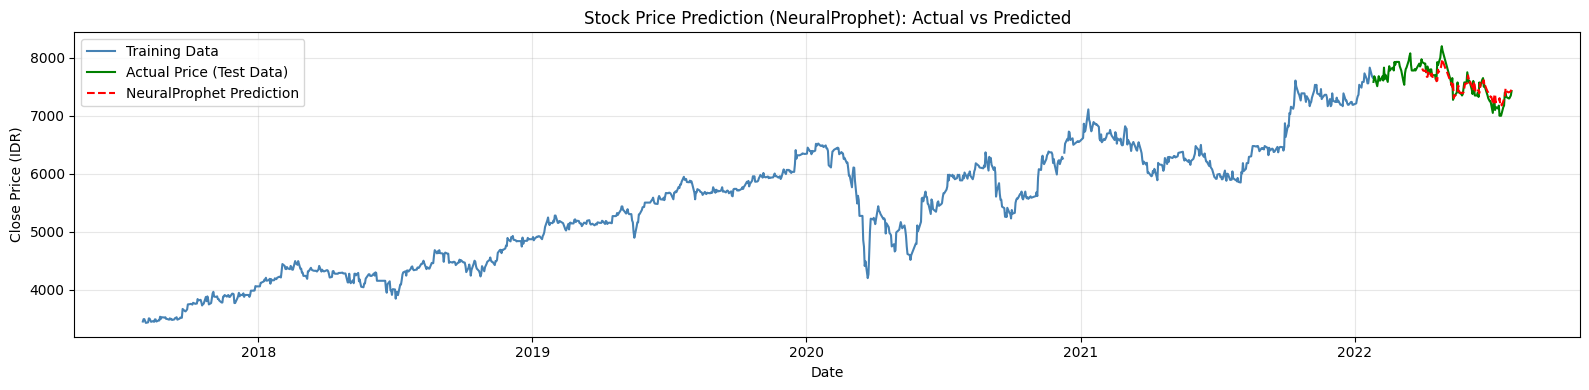

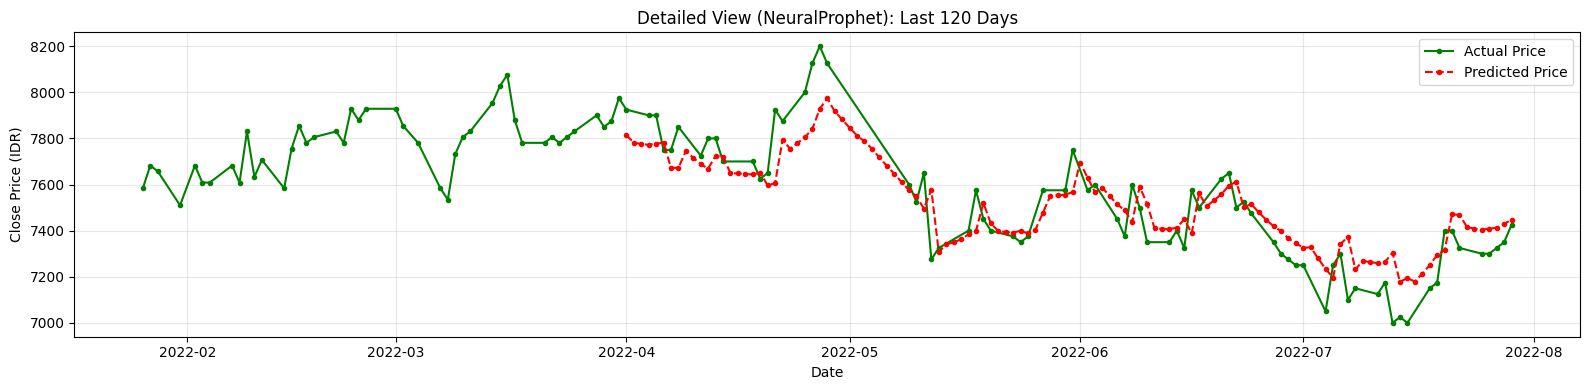

In [193]:
import pandas as pd
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet

# 1. Load raw data
PRICE_DATA_PATH = "CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx"
df_raw = pd.read_excel(PRICE_DATA_PATH)
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df_raw = df_raw.sort_values("Date")

# 2. Rename to NeuralProphet formast: ds = date, y = target
df = df_raw.rename(columns={"Date": "ds", "Close": "y"})[["ds", "y"]]

df['ds'] = pd.to_datetime(df['ds'])
print(df.dtypes)

# 3. Choose how many days you want to "treat as test"
test_size = 120

# 4. Build & fit NeuralProphet (best hyperparameters)
model = NeuralProphet(
    n_lags=1,
    n_forecasts=1,
    learning_rate=0.01,
    seasonality_mode='additive',
    epochs=100,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    quantiles=[0.05, 0.95],
)

model.add_seasonality(name="quarterly", period=91.31, fourier_order=5)

print(type(df))
print(df.columns)
print(df.head())

metrics = model.fit(df, freq="D")

# 5. Make predictions for the WHOLE history (no future steps yet)
future = model.make_future_dataframe(
    df,
    periods=0,                    # no extra future, only history
    n_historic_predictions=True   # <-- VERY IMPORTANT
)
forecast = model.predict(future)

# 6. Split into "train" and "test" segments for plotting
train_actual   = df.iloc[:-test_size].copy()
test_actual    = df.iloc[-test_size:].copy()

train_pred     = forecast.iloc[:-test_size].copy()
test_pred      = forecast.iloc[-test_size:].copy()

# 7. FULL VIEW: training + last 120 days (actual vs predicted)
plt.figure(figsize=(16, 4))

plt.plot(train_actual["ds"], train_actual["y"],
         label="Training Data", color="steelblue")

plt.plot(test_actual["ds"], test_actual["y"],
         label="Actual Price (Test Data)", color="green")

plt.plot(test_pred["ds"], test_pred["yhat1"],
         "r--", label="NeuralProphet Prediction")

# Extract actual and predicted arrays
y_true = test_actual["y"].values
y_pred = test_pred["yhat1"].values

# Compute base errors
MAE  = mean_absolute_error(y_true, y_pred)
RMSE = np.sqrt(mean_squared_error(y_true, y_pred))

# Convert to %
mean_price = np.mean(y_true)

MAE_percent  = (MAE  / mean_price) * 100
RMSE_percent = (RMSE / mean_price) * 100

print("===== NeuralProphet Performance Metrics (Last 120 Days) =====")
print(f"MAE  : {MAE:,.2f}   ({MAE_percent:.2f}%)")
print(f"RMSE : {RMSE:,.2f}   ({RMSE_percent:.2f}%)")

plt.title("Stock Price Prediction (NeuralProphet): Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Close Price (IDR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. ZOOMED VIEW: last 120 days only
plt.figure(figsize=(16, 4))

plt.plot(test_actual["ds"], test_actual["y"],
         "g.-", label="Actual Price")

plt.plot(test_pred["ds"], test_pred["yhat1"],
         "r.--", label="Predicted Price")

plt.title("Detailed View (NeuralProphet): Last 120 Days")
plt.xlabel("Date")
plt.ylabel("Close Price (IDR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [194]:
import json
import warnings
warnings.filterwarnings("ignore")

In [195]:
PRICE_DATA_PATH     = (
    "CS-IDX30 version 3/"
    "pricehistory data/Finance/BBCA.JK_dataprice.xlsx"
)
FUNDAMENTAL_PATH    = "CS-IDX30 version 3/financial report data/1/BBCA_fundamental.json"

TEST_SIZE           = 120       # last N trading days held out for evaluation
EPOCHS              = 100
LEARNING_RATE       = 0.01
N_LAGS              = 1
N_FORECASTS         = 1

# Fundamental regressors to pass into the hybrid model
REGRESSOR_COLS = [
    "net_income",
    "revenue",
    "net_profit_margin",
    "ni_growth_qoq",
    "rev_growth_qoq",
]

In [196]:
def load_price_data(path: str) -> pd.DataFrame:
    """Load BBCA price history and return a NeuralProphet-ready DataFrame."""
    df_raw = pd.read_excel(path)
    df_raw["Date"] = pd.to_datetime(df_raw["Date"])
    df_raw = df_raw.sort_values("Date").reset_index(drop=True)
    df = df_raw.rename(columns={"Date": "ds", "Close": "y"})[["ds", "y"]]
    print(f"[Price Data]  {df['ds'].min().date()} → {df['ds'].max().date()} "
          f"({len(df)} trading days)")
    return df

In [197]:
# Map quarter label → (end-month, end-day)
_QUARTER_END = {"Q1": (3, 31), "Q2": (6, 30), "Q3": (9, 30), "Q4": (12, 31)}


def _parse_value(raw: str) -> float:
    """Strip ' B' and commas then cast to float."""
    return float(raw.replace(" B", "").replace(",", ""))


def parse_quarterly_series(financial_year_values: list, col_name: str) -> pd.DataFrame:
    """
    Convert the nested year/quarter JSON structure into a tidy DataFrame with
    columns [ds, col_name], where ds is the last calendar day of the quarter.
    """
    records = []
    for year_block in financial_year_values:
        year = int(year_block["year"])
        for period in year_block["period_values"]:
            q = period["period"]
            month, day = _QUARTER_END[q]
            records.append({
                "ds":      pd.Timestamp(year=year, month=month, day=day),
                col_name:  _parse_value(period["quarter_value"]),
            })
    return pd.DataFrame(records).sort_values("ds").reset_index(drop=True)


In [ ]:
def load_fundamental_data(path: str) -> pd.DataFrame:
    """
    Parse BBCA_fundamental.json and return a quarterly DataFrame with columns:
        ds | net_income | revenue | net_profit_margin | ni_growth_qoq | rev_growth_qoq
    """
    with open(path, "r") as f:
        data = json.load(f)

    groups = data["data"]["financial_year_parent"]["financial_year_groups"]
    ni_years  = next((g["financial_year_values"] for g in groups
                      if g["fitem_name"] == "Net Income"), None)
    rev_years = next((g["financial_year_values"] for g in groups
                      if g["fitem_name"] == "Revenue"), None)

    if ni_years is None or rev_years is None:
        raise KeyError("JSON missing 'Net Income' or 'Revenue' in financial_year_groups")

    ni_df  = parse_quarterly_series(ni_years,  "net_income")
    rev_df = parse_quarterly_series(rev_years, "revenue")

    fund = ni_df.merge(rev_df, on="ds")

    # Derived features
    fund["net_profit_margin"] = fund["net_income"] / fund["revenue"].replace(0, np.nan)
    # fillna(0): first quarter has no prior quarter to compare — treat as 0% growth
    fund["ni_growth_qoq"]     = fund["net_income"].pct_change().fillna(0)
    fund["rev_growth_qoq"]    = fund["revenue"].pct_change().fillna(0)

    print(f"\n[Fundamental Data]  {len(fund)} quarterly observations "
          f"({fund['ds'].min().date()} → {fund['ds'].max().date()})")
    print(fund.to_string(index=False))
    return fund

In [199]:
def align_fundamentals_to_daily(
    df_price: pd.DataFrame,
    fund_quarterly: pd.DataFrame,
) -> pd.DataFrame:
    """
    Merge quarterly fundamental features onto the trading-day timeline via
    forward-fill.  This replicates the information set available to an
    investor: once a quarterly report is published its values persist until
    the next report is released.

    Returns the price DataFrame with fundamental columns appended, restricted
    to rows where at least one quarterly report has already been released.
    """
    # Build a full calendar-day skeleton over the price-data range
    date_range = pd.DataFrame({
        "ds": pd.date_range(df_price["ds"].min(), df_price["ds"].max(), freq="D")
    })

    # Stamp quarterly values onto their report dates, then forward-fill
    daily = (
        date_range
        .merge(fund_quarterly, on="ds", how="left")
    )
    daily[REGRESSOR_COLS] = daily[REGRESSOR_COLS].ffill()

    # Keep only dates where we already have at least one quarterly reading
    daily = daily.dropna(subset=["net_income"]).reset_index(drop=True)

    # Join back to actual trading days (drops weekends / holidays that exist
    # in the calendar but not in the price data)
    df_hybrid = df_price.merge(daily, on="ds", how="inner").reset_index(drop=True)

    print(f"\n[Hybrid Dataset]  {len(df_hybrid)} rows after alignment "
          f"({df_hybrid['ds'].min().date()} → {df_hybrid['ds'].max().date()})")
    return df_hybrid


In [200]:
def normalise_regressors(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Z-score normalise each regressor column in-place so they are on a
    comparable scale with each other before being fed into NeuralProphet.
    """
    df = df.copy()
    for col in cols:
        mu, sigma = df[col].mean(), df[col].std()
        if sigma > 0:
            df[col] = (df[col] - mu) / sigma
        else:
            df[col] = 0.0
    return df

In [201]:
def build_model(with_regressors: bool = False) -> NeuralProphet:
    """
    Instantiate a NeuralProphet model with the shared hyperparameters used in
    the original code.  If with_regressors=True, each fundamental column is
    registered as a lagged regressor.
    """
    model = NeuralProphet(
        n_lags             = N_LAGS,
        n_forecasts        = N_FORECASTS,
        learning_rate      = LEARNING_RATE,
        seasonality_mode   = "additive",
        epochs             = EPOCHS,
        yearly_seasonality = True,
        weekly_seasonality = True,
        daily_seasonality  = False,
        quantiles          = [0.05, 0.95],
    )
    model.add_seasonality(name="quarterly", period=91.31, fourier_order=5)

    if with_regressors:
        for col in REGRESSOR_COLS:
            # n_lags=1  → the model sees the most-recently available value of
            # each regressor at every prediction step, consistent with the
            # forward-fill alignment strategy
            model.add_lagged_regressor(names=col, n_lags=1)

    return model

In [202]:
def train_and_predict(
    model: NeuralProphet,
    df: pd.DataFrame,
    label: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Fit model on the full df, then predict over the entire history.
    Returns (metrics_df, forecast_df).
    """
    print(f"\n{'='*60}")
    print(f"  Training: {label}")
    print(f"{'='*60}")

    metrics  = model.fit(df, freq="D")
    future   = model.make_future_dataframe(df, periods=0, n_historic_predictions=True)
    forecast = model.predict(future)
    return metrics, forecast

In [203]:
def evaluate(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    label: str,
) -> dict:
    """Compute and print MAE, RMSE and their % equivalents."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mean = y_true.mean()

    # Directional accuracy (up/down)
    direction_actual = np.sign(np.diff(y_true))
    direction_pred   = np.sign(np.diff(y_pred))
    dir_acc = np.mean(direction_actual == direction_pred) * 100

    results = dict(
        label   = label,
        MAE     = mae,
        RMSE    = rmse,
        MAE_pct = mae  / mean * 100,
        RMSE_pct= rmse / mean * 100,
        Dir_Acc = dir_acc,
    )

    print(f"\n  ── {label} ──────────────────────────")
    print(f"  MAE        : {mae:>10,.2f}   ({results['MAE_pct']:.2f}%)")
    print(f"  RMSE       : {rmse:>10,.2f}   ({results['RMSE_pct']:.2f}%)")
    print(f"  Dir. Acc.  : {dir_acc:.2f}%")
    return results

In [204]:
def plot_fundamental_features(fund_q: pd.DataFrame) -> None:
    """Bar-chart overview of the quarterly fundamental series."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle("BBCA Quarterly Fundamental Features (from Financial Report JSON)",
                 fontsize=13, fontweight="bold")

    labels = [f"{r.ds.year}-Q{(r.ds.month - 1) // 3 + 1}" for _, r in fund_q.iterrows()]
    x = range(len(labels))

    axes[0].bar(x, fund_q["net_income"],        color="steelblue")
    axes[0].set_title("Net Income (IDR Billion)")
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=45)

    axes[1].bar(x, fund_q["revenue"],           color="darkorange")
    axes[1].set_title("Revenue (IDR Billion)")
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=45)

    axes[2].bar(x, fund_q["net_profit_margin"] * 100, color="seagreen")
    axes[2].set_title("Net Profit Margin (%)")
    axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=45)

    for ax in axes:
        ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("fundamental_features.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[Saved] fundamental_features.png")

In [ ]:
def plot_comparison(
    df_price    : pd.DataFrame,
    forecast_bl : pd.DataFrame,
    forecast_hy : pd.DataFrame,
    metrics_bl  : dict,
    metrics_hy  : dict,
    test_size   : int,
) -> None:
    """
    Four-panel comparison figure:
      (a) Full training history + test period
      (b) Zoomed last N days: actual vs baseline vs hybrid
      (c) MAE / RMSE bar chart
      (d) Directional accuracy bar chart
    """
    n = len(df_price)
    fc_bl = forecast_bl.iloc[:n].copy()
    fc_hy = forecast_hy.iloc[:n].copy()

    train_actual = df_price.iloc[:-test_size]
    test_actual  = df_price.iloc[-test_size:]
    test_bl      = fc_bl.iloc[-test_size:]
    test_hy      = fc_hy.iloc[-test_size:]

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        "BBCA NeuralProphet — Baseline vs Hybrid Multimodal Model",
        fontsize=15, fontweight="bold", y=0.98
    )
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    # ── (a) Full view ──────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(train_actual["ds"], train_actual["y"],
             color="steelblue", label="Training Data", linewidth=0.8)
    ax1.plot(test_actual["ds"],  test_actual["y"],
             color="green",     label="Actual Price (Test)", linewidth=1.2)
    ax1.plot(test_bl["ds"],      test_bl["yhat1"],
             "b--", label="Baseline Prediction", linewidth=1.1)
    ax1.plot(test_hy["ds"],      test_hy["yhat1"],
             "r--", label="Hybrid Prediction",   linewidth=1.1)
    ax1.set_title("Full History + Test Period")
    ax1.set_xlabel("Date"); ax1.set_ylabel("Close Price (IDR)")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    # ── (b) Zoomed test window ─────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(test_actual["ds"], test_actual["y"],
             "g.-", label="Actual Price",       linewidth=1.2)
    ax2.plot(test_bl["ds"],     test_bl["yhat1"],
             "b--", label=f"Baseline  MAE={metrics_bl['MAE']:,.0f}",   linewidth=1.1)
    ax2.plot(test_hy["ds"],     test_hy["yhat1"],
             "r--", label=f"Hybrid    MAE={metrics_hy['MAE']:,.0f}",   linewidth=1.1)

    # Confidence interval — NeuralProphet names quantile cols "yhat1 5.0%" / "yhat1 95.0%"
    q_lo_col = [c for c in test_hy.columns if "yhat" in c and "5.0%" in c and "95" not in c]
    q_hi_col = [c for c in test_hy.columns if "yhat" in c and "95.0%" in c]
    if q_lo_col and q_hi_col:
        ax2.fill_between(test_hy["ds"],
                         test_hy[q_lo_col[0]], test_hy[q_hi_col[0]],
                         alpha=0.15, color="red", label="Hybrid 90% CI")

    ax2.set_title(f"Zoomed View — Last {test_size} Trading Days")
    ax2.set_xlabel("Date"); ax2.set_ylabel("Close Price (IDR)")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    # ── (c) Error metrics bar chart ────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2, 0])
    metric_names = ["MAE (%)", "RMSE (%)"]
    bl_vals = [metrics_bl["MAE_pct"], metrics_bl["RMSE_pct"]]
    hy_vals = [metrics_hy["MAE_pct"], metrics_hy["RMSE_pct"]]
    x = np.arange(len(metric_names))
    width = 0.35
    b1 = ax3.bar(x - width/2, bl_vals, width, label="Baseline",
                 color="steelblue", alpha=0.85)
    b2 = ax3.bar(x + width/2, hy_vals, width, label="Hybrid",
                 color="tomato",    alpha=0.85)
    ax3.bar_label(b1, fmt="%.2f%%", padding=2, fontsize=8)
    ax3.bar_label(b2, fmt="%.2f%%", padding=2, fontsize=8)
    ax3.set_title("Error Metrics (lower is better)")
    ax3.set_xticks(x); ax3.set_xticklabels(metric_names)
    ax3.set_ylabel("% of mean price"); ax3.legend()
    ax3.grid(True, alpha=0.3, axis="y")

    # ── (d) Directional accuracy ───────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 1])
    models   = ["Baseline", "Hybrid"]
    dir_accs = [metrics_bl["Dir_Acc"], metrics_hy["Dir_Acc"]]
    bars = ax4.bar(models, dir_accs,
                   color=["steelblue", "tomato"], alpha=0.85, width=0.4)
    ax4.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9)
    ax4.axhline(50, linestyle="--", color="grey", linewidth=0.8,
                label="Random baseline (50%)")
    ax4.set_title("Directional Accuracy (higher is better)")
    ax4.set_ylabel("Accuracy (%)"); ax4.set_ylim(0, 100)
    ax4.legend(); ax4.grid(True, alpha=0.3, axis="y")

    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[Saved] model_comparison.png")

In [206]:
def plot_components_and_regressors(
    model_hybrid  : NeuralProphet,
    forecast_hy   : pd.DataFrame,
) -> None:
    """
    Plot the NeuralProphet decomposition (trend, seasonality, AR, regressors)
    for the hybrid model — core interpretability output of the thesis.
    """
    print("\n[Interpretability] Plotting hybrid model component decomposition ...")
    fig = model_hybrid.plot_components(forecast_hy)
    fig.suptitle(
        "Hybrid Model Component Decomposition\n"
        "(Trend | Seasonality | Autoregression | Fundamental Regressors)",
        fontsize=12, fontweight="bold"
    )
    plt.savefig("hybrid_components.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[Saved] hybrid_components.png")


In [207]:
def print_summary(metrics_bl: dict, metrics_hy: dict) -> None:
    improvement_mae  = (metrics_bl["MAE"]  - metrics_hy["MAE"])  / metrics_bl["MAE"]  * 100
    improvement_rmse = (metrics_bl["RMSE"] - metrics_hy["RMSE"]) / metrics_bl["RMSE"] * 100

    print("\n" + "=" * 62)
    print("  FINAL RESULTS SUMMARY")
    print("=" * 62)
    print(f"  {'Metric':<30} {'Baseline':>12} {'Hybrid':>12}")
    print(f"  {'-'*54}")
    print(f"  {'MAE (IDR)':<30} {metrics_bl['MAE']:>12,.2f} {metrics_hy['MAE']:>12,.2f}")
    print(f"  {'MAE (%)':<30} {metrics_bl['MAE_pct']:>11.2f}% {metrics_hy['MAE_pct']:>11.2f}%")
    print(f"  {'RMSE (IDR)':<30} {metrics_bl['RMSE']:>12,.2f} {metrics_hy['RMSE']:>12,.2f}")
    print(f"  {'RMSE (%)':<30} {metrics_bl['RMSE_pct']:>11.2f}% {metrics_hy['RMSE_pct']:>11.2f}%")
    print(f"  {'Directional Accuracy':<30} {metrics_bl['Dir_Acc']:>11.2f}% {metrics_hy['Dir_Acc']:>11.2f}%")
    print(f"  {'-'*54}")
    print(f"  MAE  improvement (Hybrid over Baseline) : {improvement_mae:+.2f}%")
    print(f"  RMSE improvement (Hybrid over Baseline) : {improvement_rmse:+.2f}%")
    print("=" * 62)

[Price Data]  2017-07-31 → 2022-07-29 (1256 trading days)

[Fundamental Data]  9 quarterly observations (2020-03-31 → 2022-03-31)
        ds  net_income  revenue  net_profit_margin  ni_growth_qoq  rev_growth_qoq
2020-03-31      6581.0  21769.0           0.302311            NaN             NaN
2020-06-30      5659.0  20151.0           0.280830      -0.140100       -0.074326
2020-09-30      7795.0  20281.0           0.384350       0.377452        0.006451
2020-12-31      7096.0  16362.0           0.433688      -0.089673       -0.193235
2021-03-31      7040.0  20558.0           0.342446      -0.007892        0.256448
2021-06-30      7416.0  20667.0           0.358833       0.053409        0.005302
2021-09-30      8743.0  20571.0           0.425016       0.178937       -0.004645
2021-12-31      8224.0  18511.0           0.444276      -0.059362       -0.100141
2022-03-31      8064.0  21050.0           0.383088      -0.019455        0.137162


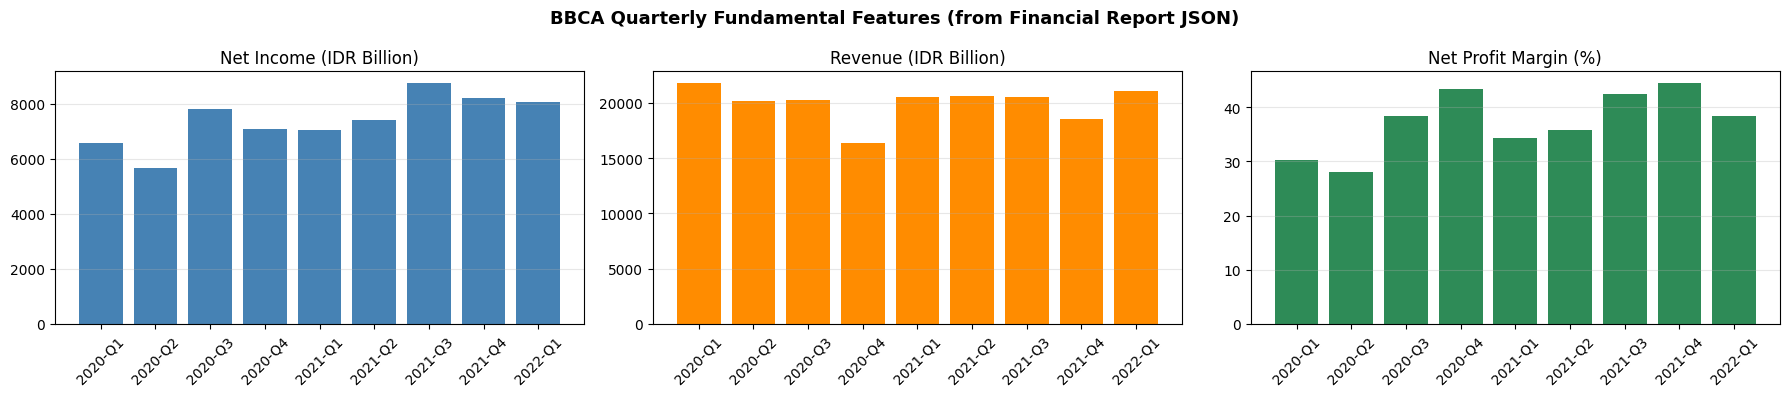

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.513% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Added 286 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 287 missing values in column y were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 287 NaN values in column y were auto-imputed.
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32


[Saved] fundamental_features.png

[Hybrid Dataset]  565 rows after alignment (2020-03-31 → 2022-07-29)

  Training: Baseline (Price-Only)


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

WARNING - (NP.data.splitting._make_future_dataframe) - Not extending df into future as no periods specified. You can skip this and predict directly instead.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.513% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.513% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.513% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Added 286 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 287 missing values in column y were detected in total. 
INFO - (NP.data.proces

Predicting: 0it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 94.513% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Added 286 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 287 missing values in column y were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 287 NaN values in column y were auto-imputed.
WARNING - (NP.data.processing._handle_missing_data) - 286 missing values in column net_income were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 286 NaN values in column net_income were auto-imputed.
WARNING - (NP.data.processing._handle_missing_data) - 286 missing values in column revenue were detecte


  Training: Hybrid (Price + Fundamentals)


ValueError: Inputs/targets with missing values detected. Please either adjust imputation parameters, or set 'drop_missing' to True to drop those samples.

In [208]:
def main():
    # ── 1. Load data ───────────────────────────────────────────────────────────
    df_price   = load_price_data(PRICE_DATA_PATH)
    fund_q     = load_fundamental_data(FUNDAMENTAL_PATH)

    # ── 2. Visualise quarterly fundamentals ───────────────────────────────────
    plot_fundamental_features(fund_q)

    # ── 3. Align fundamentals to daily trading days ────────────────────────────
    df_hybrid = align_fundamentals_to_daily(df_price, fund_q)
    df_hybrid = normalise_regressors(df_hybrid, REGRESSOR_COLS)

    # Price-only slice (same date range so comparison is fair)
    df_price_aligned = df_hybrid[["ds", "y"]].copy()

    # ── 4. BASELINE — price only ───────────────────────────────────────────────
    model_baseline            = build_model(with_regressors=False)
    _, forecast_baseline      = train_and_predict(
        model_baseline, df_price_aligned, "Baseline (Price-Only)"
    )

    # ── 5. HYBRID — price + fundamentals ──────────────────────────────────────
    model_hybrid              = build_model(with_regressors=True)
    _, forecast_hybrid        = train_and_predict(
        model_hybrid,
        df_hybrid[["ds", "y"] + REGRESSOR_COLS],
        "Hybrid (Price + Fundamentals)"
    )

    # ── 6. Evaluate on the held-out test window ────────────────────────────────
    n                 = len(df_price_aligned)
    y_true            = df_price_aligned["y"].values[-TEST_SIZE:]

    y_pred_bl         = forecast_baseline["yhat1"].values[:n][-TEST_SIZE:]
    y_pred_hy         = forecast_hybrid["yhat1"].values[:n][-TEST_SIZE:]

    print("\n" + "=" * 62)
    print("  EVALUATION RESULTS  (last {} trading days)".format(TEST_SIZE))
    print("=" * 62)
    metrics_bl = evaluate(y_true, y_pred_bl, "Baseline (Price-Only)")
    metrics_hy = evaluate(y_true, y_pred_hy, "Hybrid (Price + Fundamentals)")

    # ── 7. Plots ───────────────────────────────────────────────────────────────
    plot_comparison(
        df_price_aligned,
        forecast_baseline,
        forecast_hybrid,
        metrics_bl,
        metrics_hy,
        TEST_SIZE,
    )

    plot_components_and_regressors(model_hybrid, forecast_hybrid)

    # ── 8. Summary ────────────────────────────────────────────────────────────
    print_summary(metrics_bl, metrics_hy)


if __name__ == "__main__":
    main()